In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Load — this may take 10–15 seconds on the first run
df = pd.read_csv('../data/SGJobData.csv', low_memory=False)

In [4]:
# Sanity checks
print(df.shape)          # Expect (~1048585, 20)
print(df.dtypes)
print(df.head(3))

(1048585, 22)
categories                             object
employmentTypes                        object
metadata_expiryDate                    object
metadata_isPostedOnBehalf                bool
metadata_jobPostId                     object
metadata_newPostingDate                object
metadata_originalPostingDate           object
metadata_repostCount                    int64
metadata_totalNumberJobApplication      int64
metadata_totalNumberOfView              int64
minimumYearsExperience                  int64
numberOfVacancies                       int64
occupationId                          float64
positionLevels                         object
postedCompany_name                     object
salary_maximum                          int64
salary_minimum                          int64
salary_type                            object
status_id                               int64
status_jobStatus                       object
title                                  object
average_salary      

In [5]:
# Data Cleaning

df['metadata_originalPostingDate'] = pd.to_datetime(df['metadata_originalPostingDate'])
df['metadata_newPostingDate']       = pd.to_datetime(df['metadata_newPostingDate'])
df['metadata_expiryDate']           = pd.to_datetime(df['metadata_expiryDate'])

In [6]:
df

,categories,employmentTypes,metadata_expiryDate,metadata_isPostedOnBehalf,metadata_jobPostId,metadata_newPostingDate,metadata_originalPostingDate,metadata_repostCount,metadata_totalNumberJobApplication,metadata_totalNumberOfView,...,occupationId,positionLevels,postedCompany_name,salary_maximum,salary_minimum,salary_type,status_id,status_jobStatus,title,average_salary
0,"[{""id"":13,""category"":""Environment / Health""},{...",Permanent,2023-05-08,False,MCF-2023-0252866,2023-04-08,2023-03-30,2,5,151,...,NaN,Executive,WORKSTONE PTE. LTD.,2800,2000,Monthly,0,Closed,Food Technologist - Clementi | Entry Level | U...,2400.0
1,"[{""id"":21,""category"":""Information Technology""}]",Permanent,2023-05-08,False,MCF-2023-0273977,2023-04-08,2023-04-08,0,0,55,...,NaN,Executive,TRUST RECRUIT PTE. LTD.,5500,4000,Monthly,0,Closed,"Software Engineer (Fab Support) (Java, CIM, Up...",4750.0
2,"[{""id"":33,""category"":""Repair and Maintenance""}]",Full Time,2023-04-22,False,MCF-2023-0273994,2023-04-08,2023-04-08,0,7,99,...,NaN,Senior Executive,PU TIEN SERVICES PTE. LTD.,4600,3800,Monthly,0,Closed,Senior Technician,4200.0
3,"[{""id"":21,""category"":""Information Technology""}]",Permanent,2023-05-08,False,MCF-2023-0273991,2023-04-08,2023-04-08,0,6,113,...,NaN,Senior Executive,TRUST RECRUIT PTE. LTD.,10000,5000,Monthly,0,Closed,"Senior .NET Developer (.NET Core, MVC, MVVC, S...",7500.0
4,"[{""id"":2,""category"":""Admin / Secretarial""}]",Full Time,2023-05-08,False,MCF-2023-0273976,2023-04-08,2023-04-08,0,3,99,...,NaN,Non-executive,EATZ CATERING SERVICES PTE. LTD.,3400,2400,Monthly,0,Closed,Sales / Admin Cordinator,2900.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048580,"[{""id"":4,""category"":""Architecture / Interior D...",Part Time,2024-07-22,False,RANDOM_JOB_20251115011348190957_5,2023-10-06,2023-09-30,1,1111,2370,...,NaN,Senior Management,SAFRAN LANDING SYSTEMS SERVICES SINGAPORE PTE....,23712119,14719,Monthly,0,Re-open,Executive Secretary,11863419.0
1048581,"[{""id"":16,""category"":""General Management""},{""i...",Freelance,2024-03-18,False,RANDOM_JOB_20251115011348553903_6,2023-09-04,2023-08-12,1,131,1626,...,NaN,Executive,RECRUIT EXPRESS PTE LTD,7859259,267303,Monthly,0,Closed,Junior Project Manager (IT Infrastructure),4063281.0
1048582,"[{""id"":2,""category"":""Admin / Secretarial""},{""i...",Contract,2023-08-16,False,RANDOM_JOB_20251115011348901570_7,2023-02-24,2023-01-26,1,580,3912,...,NaN,Executive,MINDFLEX EDUCATION PTE. LTD.,13798518,260117,Monthly,0,Re-open,Social media content creator,7029317.5
1048583,"[{""id"":2,""category"":""Admin / Secretarial""},{""i...",Internship/Attachment,2024-10-11,False,RANDOM_JOB_20251115011349285489_8,2024-01-22,2024-01-03,0,465,2281,...,NaN,Professional,YUANYII AGENCY PTE. LTD.,3986060,17155,Monthly,0,Closed,Junior Sous Chef,2001607.5


# Basic Exploration
## Loading and initial profiling:

In [7]:
# # Shape, types, missing values at a glance
print(f"Rows: {df.shape[0]:,}  Columns: {df.shape[1]}")
print("\nNull counts:\n", df.isnull().sum().sort_values(ascending=False).head(10))
print("\nBasic stats:\n", df[['salary_minimum','salary_maximum','average_salary',
                               'minimumYearsExperience','numberOfVacancies']].describe())

Rows: 1,048,585  Columns: 22

Null counts:
 occupationId                    1048585
categories                         3988
metadata_expiryDate                3988
title                              3988
metadata_jobPostId                 3988
metadata_newPostingDate            3988
metadata_originalPostingDate       3988
status_jobStatus                   3988
salary_type                        3988
employmentTypes                    3988
dtype: int64

Basic stats:
        salary_minimum  salary_maximum  average_salary  minimumYearsExperience  \
count    1.048585e+06    1.048585e+06    1.048585e+06            1.048585e+06   
mean     3.815312e+03    5.723578e+03    4.769445e+03            2.779573e+00   
std      3.172182e+03    5.018387e+04    2.547809e+04            2.537049e+00   
min      0.000000e+00    0.000000e+00    0.000000e+00            0.000000e+00   
25%      2.500000e+03    3.300000e+03    2.900000e+03            1.000000e+00   
50%      3.000000e+03    4.500000e+03    3

## Salary cleaning with NumPy:

In [8]:
# Remove obvious outliers using the 99th percentile
p99 = np.percentile(df['average_salary'].dropna(), 99)
df_clean = df[(df['average_salary'] > 500) & (df['average_salary'] <= p99)].copy()

# Use NumPy to compute stats on the cleaned array
sal = df_clean['average_salary'].to_numpy()
print(f"Mean: {np.mean(sal):,.0f}  Median: {np.median(sal):,.0f}  Std: {np.std(sal):,.0f}")
print(f"25th pct: {np.percentile(sal, 25):,.0f}  75th pct: {np.percentile(sal, 75):,.0f}")


Mean: 4,551  Median: 3,800  Std: 2,533
25th pct: 2,900  75th pct: 5,500


## Groupby aggregation — salary by position level:

In [9]:
salary_by_level = (
    df_clean
    .groupby('positionLevels')['average_salary']
    .agg(['mean', 'median', 'count'])
    .rename(columns={'mean': 'avg_salary', 'median': 'median_salary', 'count': 'num_jobs'})
    .sort_values('median_salary', ascending=False)
)

print(salary_by_level)

                    avg_salary  median_salary  num_jobs
positionLevels                                         
Senior Management  9166.091606         8750.0     19644
Middle Management  7017.119383         6300.0     25925
Manager            6605.116159         6000.0    108347
Professional       6647.986773         6000.0    108489
Senior Executive   5586.637209         5000.0     99636
Executive          4119.707783         3750.0    252595
Junior Executive   3380.171451         3150.0    166809
Non-executive      3000.358858         2750.0    129472
Fresh/entry level  2793.007436         2600.0    115659


## Parsing the categories JSON string (one row → first category)

In [10]:
import re

def extract_first_category(cat_str):
    """Extract the first category label from the JSON-like string."""
    if pd.isna(cat_str):
        return np.nan
    match = re.search(r'"category"\s*:\s*"([^"]+)"', str(cat_str))
    return match.group(1) if match else np.nan

df_clean['primary_category'] = df_clean['categories'].apply(extract_first_category)
print(df_clean['primary_category'].value_counts().head(10))


Admin / Secretarial                 101660
Engineering                          99050
Information Technology               97682
Accounting / Auditing / Taxation     77696
Building and Construction            73640
Customer Service                     63867
F&B                                  58830
Logistics / Supply Chain             44039
Banking and Finance                  44033
Sales / Retail                       36604
Name: primary_category, dtype: int64


## Monthly posting trend:

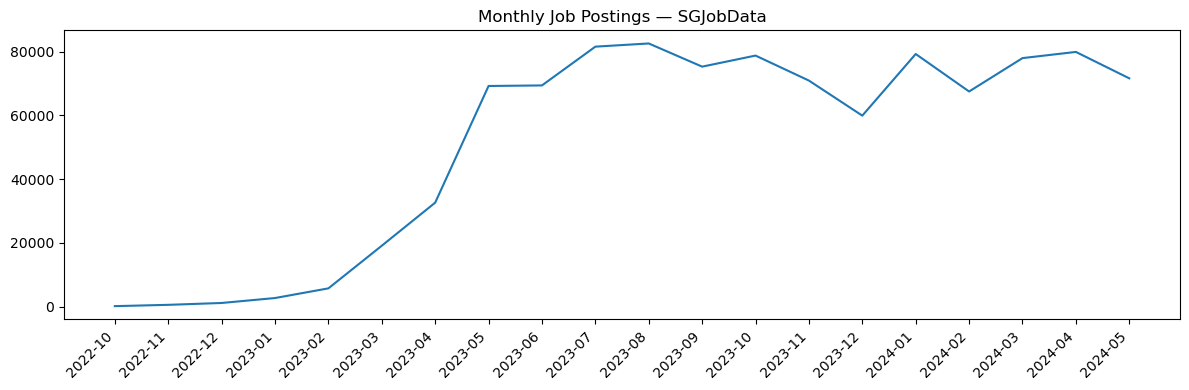

In [11]:
df_clean['year_month'] = df_clean['metadata_originalPostingDate'].dt.to_period('M')
monthly = df_clean.groupby('year_month').size().reset_index(name='postings')

plt.figure(figsize=(12, 4))
plt.plot(monthly['year_month'].astype(str), monthly['postings'])
plt.xticks(rotation=45, ha='right')
plt.title('Monthly Job Postings — SGJobData')
plt.tight_layout()
plt.show()

## Job Type Analysis


In [43]:
# Number of jobs by industry - Overall 

df_clean['primary_category'].value_counts().head(10)

Admin / Secretarial                 101660
Engineering                          99050
Information Technology               97682
Accounting / Auditing / Taxation     77696
Building and Construction            73640
Customer Service                     63867
F&B                                  58830
Logistics / Supply Chain             44039
Banking and Finance                  44033
Sales / Retail                       36604
Name: primary_category, dtype: int64

In [44]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1026576 entries, 0 to 1048574
Data columns (total 24 columns):
 #   Column                              Non-Null Count    Dtype         
---  ------                              --------------    -----         
 0   categories                          1026576 non-null  object        
 1   employmentTypes                     1026576 non-null  object        
 2   metadata_expiryDate                 1026576 non-null  datetime64[ns]
 3   metadata_isPostedOnBehalf           1026576 non-null  bool          
 4   metadata_jobPostId                  1026576 non-null  object        
 5   metadata_newPostingDate             1026576 non-null  datetime64[ns]
 6   metadata_originalPostingDate        1026576 non-null  datetime64[ns]
 7   metadata_repostCount                1026576 non-null  int64         
 8   metadata_totalNumberJobApplication  1026576 non-null  int64         
 9   metadata_totalNumberOfView          1026576 non-null  int64         

# Comparing Agencies/companies

In [86]:
# Remove all rows from Recruitment agencies and similar intermediaries

agency_keywords = ['RECRUIT', 'HR ADVISORY', 'MANPOWER', 'STAFFING', 'CONSULT', 'TALENT']
pattern = '|'.join(agency_keywords) # create a single string pattern for regex search

agency_only = df_clean[
    (df_clean['postedCompany_name'].str.upper().str.contains(pattern, na=False)) & # Exclude rows where company name contains any of the agency keywords
    (df_clean['metadata_isPostedOnBehalf'] == True) # Exclude rows where the job is posted on behalf of another company (likely agencies)
]

direct_only = df_clean[
    (~df_clean['postedCompany_name'].str.upper().str.contains(pattern, na=False)) & # Exclude rows where company name contains any of the agency keywords
    (df_clean['metadata_isPostedOnBehalf'] == False) # Exclude rows where the job is posted on behalf of another company (likely agencies)
]

direct_only.head()


,categories,employmentTypes,metadata_expiryDate,metadata_isPostedOnBehalf,metadata_jobPostId,metadata_newPostingDate,metadata_originalPostingDate,metadata_repostCount,metadata_totalNumberJobApplication,metadata_totalNumberOfView,...,postedCompany_name,salary_maximum,salary_minimum,salary_type,status_id,status_jobStatus,title,average_salary,primary_category,year_month
0,"[{""id"":13,""category"":""Environment / Health""},{...",Permanent,2023-05-08,False,MCF-2023-0252866,2023-04-08,2023-03-30,2,5,151,...,WORKSTONE PTE. LTD.,2800,2000,Monthly,0,Closed,Food Technologist - Clementi | Entry Level | U...,2400.0,Environment / Health,2023-03
2,"[{""id"":33,""category"":""Repair and Maintenance""}]",Full Time,2023-04-22,False,MCF-2023-0273994,2023-04-08,2023-04-08,0,7,99,...,PU TIEN SERVICES PTE. LTD.,4600,3800,Monthly,0,Closed,Senior Technician,4200.0,Repair and Maintenance,2023-04
4,"[{""id"":2,""category"":""Admin / Secretarial""}]",Full Time,2023-05-08,False,MCF-2023-0273976,2023-04-08,2023-04-08,0,3,99,...,EATZ CATERING SERVICES PTE. LTD.,3400,2400,Monthly,0,Closed,Sales / Admin Cordinator,2900.0,Admin / Secretarial,2023-04
7,"[{""id"":37,""category"":""Security and Investigati...",Permanent,2023-05-08,False,MCF-2023-0273993,2023-04-08,2023-04-08,0,9,137,...,TRITON AI PTE. LTD.,7000,6500,Monthly,0,Closed,IT Security Engineer (Maritime/ Cloud Security),6750.0,Security and Investigation,2023-04
8,"[{""id"":1,""category"":""Accounting / Auditing / T...",Permanent,2023-05-12,False,MCF-2023-0261996,2023-04-12,2023-04-04,2,5,82,...,WORKSTONE PTE. LTD.,5500,3000,Monthly,0,Closed,Assistant Sales Manager (Hunter Role)- Up to $...,4250.0,Accounting / Auditing / Taxation,2023-04


In [87]:
# Agency only jobs 

agency_only.groupby(['primary_category','employmentTypes','positionLevels'])['average_salary'].mean().sort_values(ascending=False)

primary_category                employmentTypes  positionLevels   
Banking and Finance             Contract         Professional         16500.000000
Architecture / Interior Design  Contract         Senior Management    16000.000000
Legal                           Permanent        Manager              15525.000000
Information Technology          Contract         Manager              14000.000000
Advertising / Media             Permanent        Senior Management    13833.333333
                                                                          ...     
Others                          Contract         Non-executive         1200.000000
Admin / Secretarial             Part Time        Fresh/entry level     1000.000000
Others                          Part Time        Non-executive         1000.000000
Admin / Secretarial             Part Time        Non-executive          850.000000
Healthcare / Pharmaceutical     Part Time        Fresh/entry level      720.000000
Name: average_salary

In [ ]:
# Direct only jobs 

direct_only.groupby(['primary_category','employmentTypes','positionLevels'])['average_salary'].mean().sort_values(ascending=False)

primary_category                   employmentTypes        positionLevels   
Purchasing / Merchandising         Contract               Senior Management    16000.000000
Sales / Retail                     Temporary              Professional         15900.000000
Hospitality                        Contract               Middle Management    15750.000000
General Management                 Part Time              Middle Management    15000.000000
Real Estate / Property Management  Temporary              Senior Management    15000.000000
                                                                                   ...     
Sales / Retail                     Temporary              Senior Executive       750.000000
Professional Services              Internship/Attachment  Non-executive          700.000000
Education and Training             Internship/Attachment  Executive              650.000000
Events / Promotions                Freelance              Fresh/entry level      585.333333
Gene

In [ ]:
# Create a combined df 
agency_only['Source'] = 'Agency'
direct_only['Source'] = 'Direct'
combined_df = pd.concat([agency_only, direct_only], ignore_index=True)

/var/folders/v0/6z8pjvr11kn3v9fr5dv27sv00000gp/T/ipykernel_17551/3236814888.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  agencies_only['Source'] = 'Agency'
/var/folders/v0/6z8pjvr11kn3v9fr5dv27sv00000gp/T/ipykernel_17551/3236814888.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  direct_only['Source'] = 'Direct'


## Number of jobs by Industry for each source 

In [96]:
job_count_compare = combined_df.pivot_table(index='primary_category', columns='Source', values='metadata_jobPostId', aggfunc='count')
job_count_compare = job_count_compare.reset_index()
job_count_compare = job_count_compare.sort_values(by='Direct', ascending=False)
job_count_compare.columns.name = None
job_count_compare_top10 = job_count_compare.head(10)
job_count_compare_top10

,primary_category,Agency,Direct
20,Information Technology,324.0,71613.0
1,Admin / Secretarial,372.0,64563.0
5,Building and Construction,1112.0,57299.0
10,Engineering,835.0,51554.0
0,Accounting / Auditing / Taxation,325.0,46658.0
14,F&B,2529.0,43338.0
7,Customer Service,1830.0,41688.0
4,Banking and Finance,137.0,31913.0
23,Logistics / Supply Chain,322.0,25038.0
9,Education and Training,91.0,24524.0


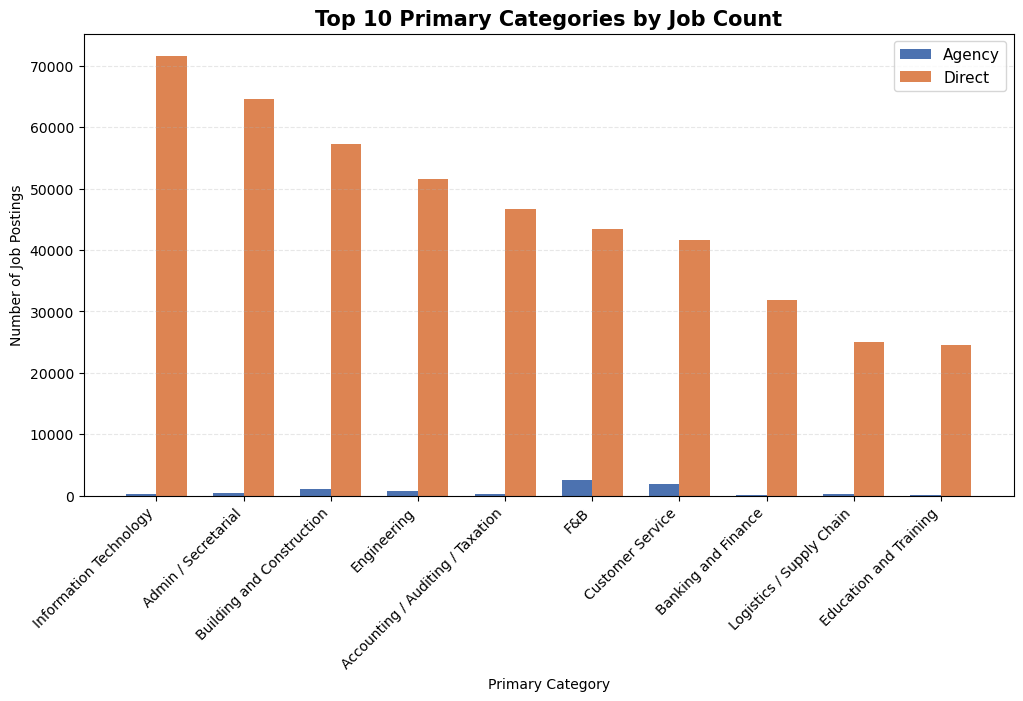

In [100]:
plot_df = job_count_compare_top10.copy()

x = np.arange(len(plot_df))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    x - width/2,
    plot_df['Agency'],
    width,
    label='Agency',
    color='#4C72B0'
)

ax.bar(
    x + width/2,
    plot_df['Direct'],
    width,
    label='Direct',
    color='#DD8452'
)

ax.set_title('Top 10 Primary Categories by Job Count', fontsize=15, fontweight='bold')
ax.set_xlabel('Primary Category')
ax.set_ylabel('Number of Job Postings')

ax.set_xticks(x)
ax.set_xticklabels(plot_df['primary_category'].astype(str), rotation=45, ha='right')

ax.grid(axis='y', linestyle='--', alpha=0.3)

ax.legend(
    loc='upper right',
    frameon=True,
    fontsize=11
)

plt.show()

## Average Salary by Industry for each source

In [98]:
avg_salary_compare = combined_df.pivot_table(index='primary_category', columns='Source', values='average_salary', aggfunc='mean')
avg_salary_compare = avg_salary_compare.reset_index()
avg_salary_compare = avg_salary_compare.sort_values(by='Direct', ascending=False)
avg_salary_compare.columns.name = None
avg_salary_compare_top10 = avg_salary_compare.head(10)
# avg_salary_compare_top10 = avg_salary_compare_top10.reset_index()
# avg_salary_compare_top10 = avg_salary_compare_top10.drop(columns=['index'])
avg_salary_compare_top10

,primary_category,Agency,Direct
22,Legal,9550.000000,7487.383277
35,Risk Management,NaN,7416.630708
4,Banking and Finance,8054.864964,7241.562874
20,Information Technology,7186.149691,7192.010152
6,Consulting,5294.849624,6592.583592
40,Telecommunications,5675.000000,6273.302752
21,Insurance,NaN,6134.017378
15,General Management,4393.201033,6000.609233
37,Sciences / Laboratory / R&D,3915.625000,5881.444604
10,Engineering,4962.844311,5171.063128


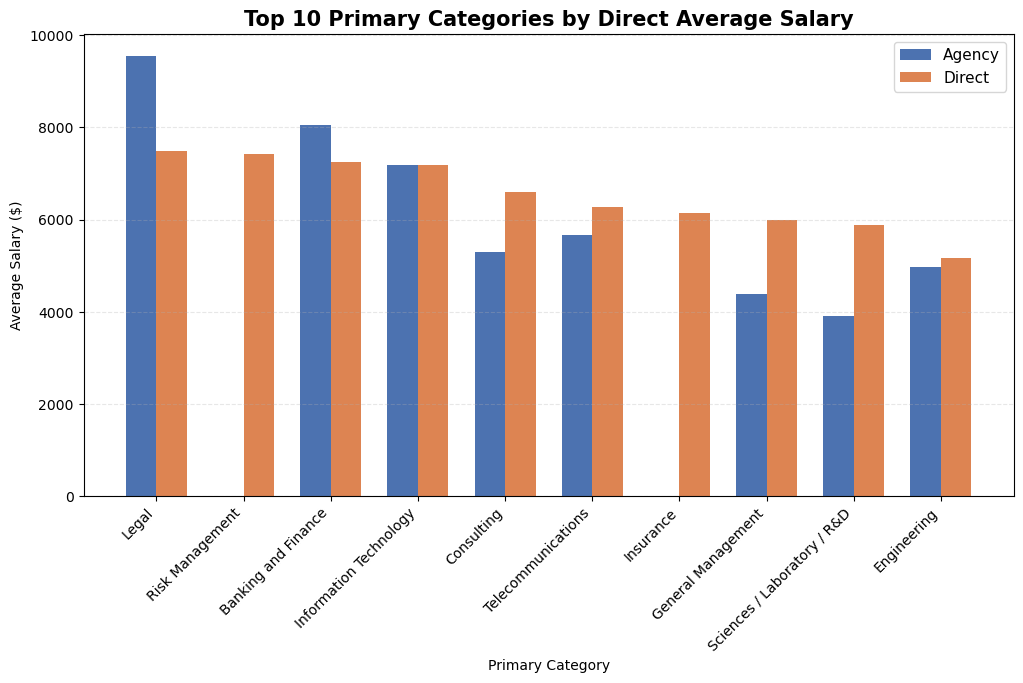

In [99]:
plot_df = avg_salary_compare_top10.copy()

x = np.arange(len(plot_df))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(
    x - width/2,
    plot_df['Agency'],
    width,
    label='Agency',
    color='#4C72B0'
)

ax.bar(
    x + width/2,
    plot_df['Direct'],
    width,
    label='Direct',
    color='#DD8452'
)

ax.set_title('Top 10 Primary Categories by Direct Average Salary', fontsize=15, fontweight='bold')
ax.set_xlabel('Primary Category')
ax.set_ylabel('Average Salary ($)')

ax.set_xticks(x)
ax.set_xticklabels(plot_df['primary_category'].astype(str), rotation=45, ha='right')

ax.grid(axis='y', linestyle='--', alpha=0.3)

ax.legend(
    loc='upper right',
    frameon=True,
    fontsize=11
)

plt.show()

## General Salary and Job Count Trends

In [103]:
general_salary_trend = combined_df.pivot_table(index='year_month', columns='Source', values='average_salary', aggfunc='mean').reset_index()
general_salary_trend.columns.name = None

general_jobcount_trend = combined_df.pivot_table(index='year_month', columns='Source', values='metadata_jobPostId', aggfunc='count').reset_index()
general_jobcount_trend.columns.name = None

general_trend = general_salary_trend.merge(general_jobcount_trend, on='year_month', how='left')

general_trend = general_trend.rename(columns={
    'Agency_x': 'Avg Salary (Agency)',
    'Direct_x': 'Avg Salary (Direct)',
    'Agency_y': 'Job Count (Agency)',
    'Direct_y': 'Job Count (Direct)'
})

general_trend = general_trend[['year_month', 'Avg Salary (Agency)', 'Job Count (Agency)', 'Avg Salary (Direct)', 'Job Count (Direct)']]
general_trend

,year_month,Avg Salary (Agency),Job Count (Agency),Avg Salary (Direct),Job Count (Direct)
0,2022-10,2833.333333,3,4065.198718,156
1,2022-11,4433.333333,9,4355.677734,512
2,2022-12,3921.276596,47,4301.188211,967
3,2023-01,4314.062500,32,4188.377073,2412
4,2023-02,4778.571429,35,4159.535664,5005
5,2023-03,4533.641975,162,4461.226897,13418
6,2023-04,4334.559585,386,4603.921940,22457
7,2023-05,4491.526185,802,4769.465849,45313
8,2023-06,4188.692529,1740,4723.637761,44167
9,2023-07,4492.527519,1181,4750.983285,52858


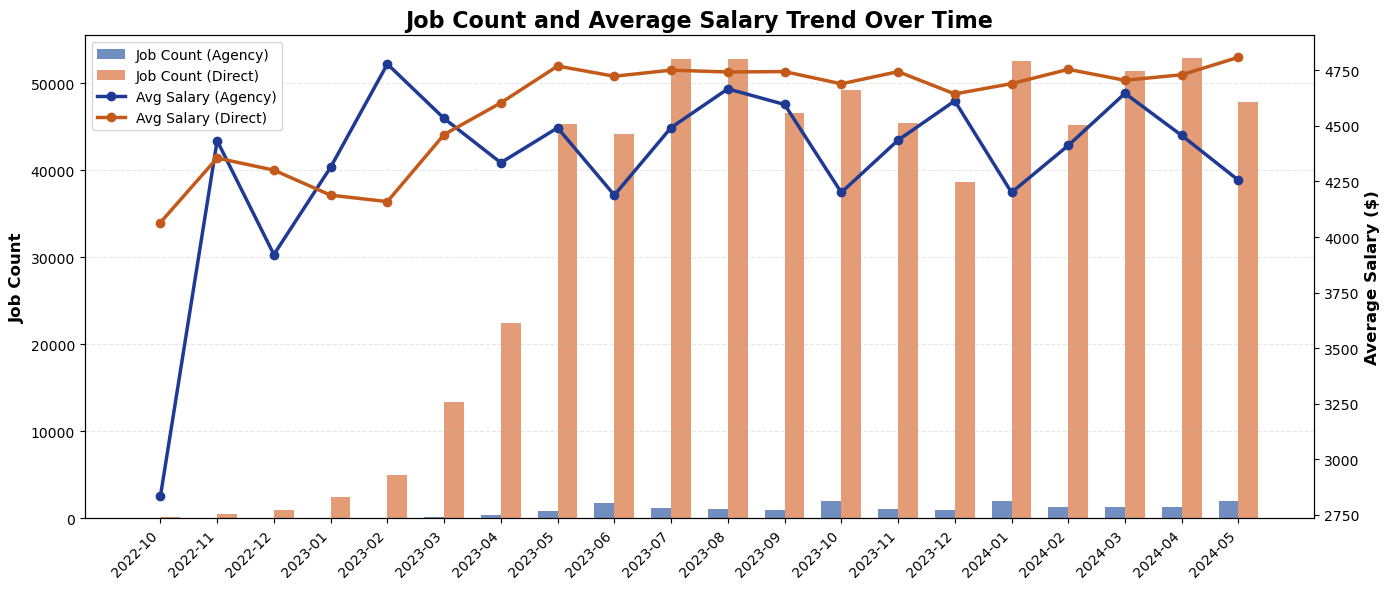

In [95]:
plot_df = general_trend.copy()

# Ensure string type for plotting
plot_df["year_month"] = plot_df["year_month"].astype(str)

x = np.arange(len(plot_df))
width = 0.35

fig, ax1 = plt.subplots(figsize=(14, 6))


# LEFT Y-AXIS → JOB COUNTS (BAR)

bars1 = ax1.bar(
    x - width/2,
    plot_df["Job Count (Agency)"],
    width,
    label="Job Count (Agency)",
    color="#4C72B0",
    alpha=0.8
)

bars2 = ax1.bar(
    x + width/2,
    plot_df["Job Count (Direct)"],
    width,
    label="Job Count (Direct)",
    color="#DD8452",
    alpha=0.8
)

ax1.set_ylabel(
    "Job Count",
    fontsize=12,
    fontweight="bold"
)


# RIGHT Y-AXIS → AVG SALARY (LINE)

ax2 = ax1.twinx()

line1 = ax2.plot(
    x,
    plot_df["Avg Salary (Agency)"],
    color="#1F3A93",
    marker="o",
    linewidth=2.5,
    label="Avg Salary (Agency)"
)

line2 = ax2.plot(
    x,
    plot_df["Avg Salary (Direct)"],
    color="#C45A1A",
    marker="o",
    linewidth=2.5,
    label="Avg Salary (Direct)"
)

ax2.set_ylabel(
    "Average Salary ($)",
    fontsize=12,
    fontweight="bold"
)


# X-AXIS


ax1.set_xticks(x)
ax1.set_xticklabels(
    plot_df["year_month"],
    rotation=45,
    ha="right"
)


# TITLE


plt.title(
    "Job Count and Average Salary Trend Over Time",
    fontsize=16,
    fontweight="bold"
)

# GRID

ax1.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)


# COMBINED LEGEND

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left",
    fontsize=10
)

plt.tight_layout()
plt.show()

## Use of Agency over time and within specific industries 

<Axes: xlabel='year_month'>

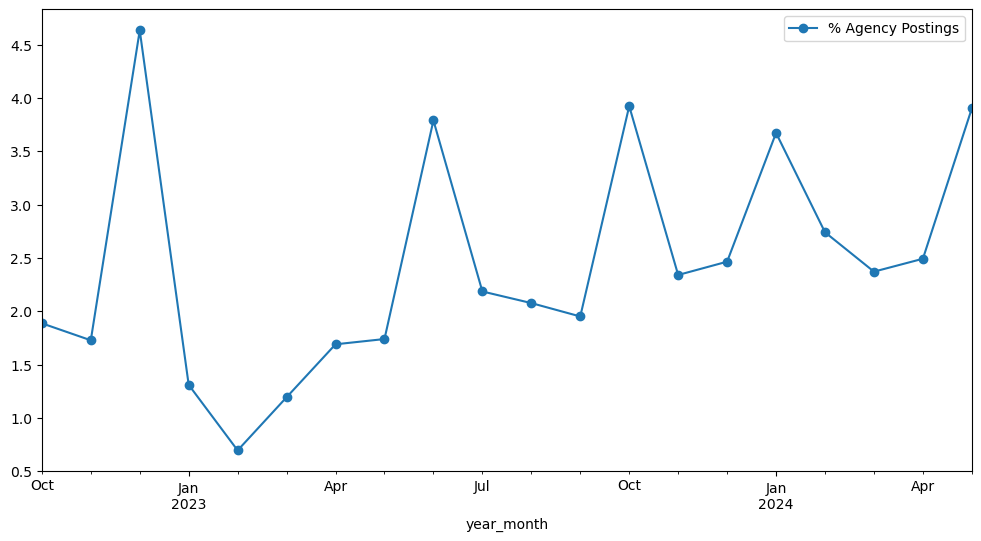

In [108]:
# % Of Agency postings over time 

general_trend['% Agency Postings'] = (general_trend['Job Count (Agency)'] / (general_trend['Job Count (Agency)'] + general_trend['Job Count (Direct)'])) * 100
general_trend.plot(
    x="year_month",
    y="% Agency Postings",
    kind="line",
    figsize=(12, 6),
    marker="o"
)

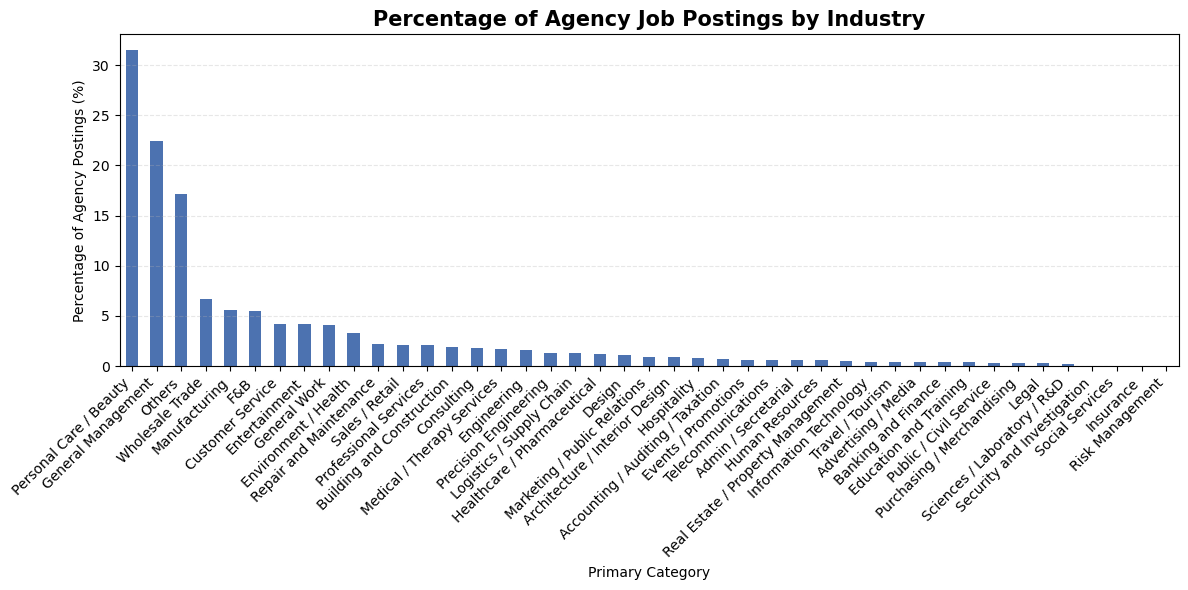

In [114]:
# Use of Agency per industry 

job_count_compare['% Agency'] = (job_count_compare['Agency'] / (job_count_compare['Agency'] + job_count_compare['Direct'])) * 100
job_count_compare = job_count_compare.sort_values(by='% Agency', ascending=False)

job_count_compare = job_count_compare.sort_values(
    by='% Agency',
    ascending=False
)

# Plot
job_count_compare.plot(
    x='primary_category',
    y='% Agency',
    kind='bar',
    figsize=(12, 6),
    color='#4C72B0',
    legend=False
)

plt.title(
    'Percentage of Agency Job Postings by Industry',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Primary Category')
plt.ylabel('Percentage of Agency Postings (%)')

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Filter for specific employment types, position levels, and categories

Using the below filters for this section:

Industry = Banking and Finance

Position Level = Executive (using the most common option as per below)

Employee Type = Permanent (using the most common type as per below)

## General Salary Comparison

In [81]:
# Change Fitlers Below as needed 

# filter_source = (combined_df['Source'].isin(['Direct']))
filter_employtype = (combined_df['employmentTypes'].isin(['Permanent']))
filter_position = (combined_df['positionLevels'].isin(['Executive']))
filter_cat = (combined_df['primary_category'].isin(['Banking and Finance']))

most_common_positions = combined_df[filter_cat & filter_employtype].groupby(['positionLevels'])['metadata_jobPostId'].count().sort_values(ascending=False)
most_common_employment_types= combined_df[filter_cat & filter_position].groupby(['employmentTypes'])['metadata_jobPostId'].count().sort_values(ascending=False)

print(most_common_positions)
print(most_common_employment_types)

positionLevels
Executive            3016
Professional         2495
Manager              2450
Senior Executive     2291
Fresh/entry level    1446
Junior Executive     1306
Middle Management     860
Senior Management     649
Non-executive         225
Name: metadata_jobPostId, dtype: int64
employmentTypes
Permanent                3016
Full Time                2152
Contract                 1503
Part Time                  52
Freelance                  42
Temporary                  36
Internship/Attachment       1
Name: metadata_jobPostId, dtype: int64


In [46]:
# Apply filters to the combined dataframe

filtered_df = combined_df[filter_employtype & filter_position & filter_cat]
compare_avg_salary = filtered_df.groupby('Source')['average_salary'].mean()
compare_avg_salary = compare_avg_salary.reset_index()

compare_counts = filtered_df.groupby('Source')['metadata_jobPostId'].count().reset_index(name='num_jobs')
compare_counts = compare_counts.reset_index()

combined_compare = compare_avg_salary.merge(compare_counts, on='Source', how='left')
combined_compare = combined_compare.drop(columns=['index'])
combined_compare

,Source,average_salary,num_jobs
0,Agency,6885.947368,19
1,Direct,6026.511345,2997


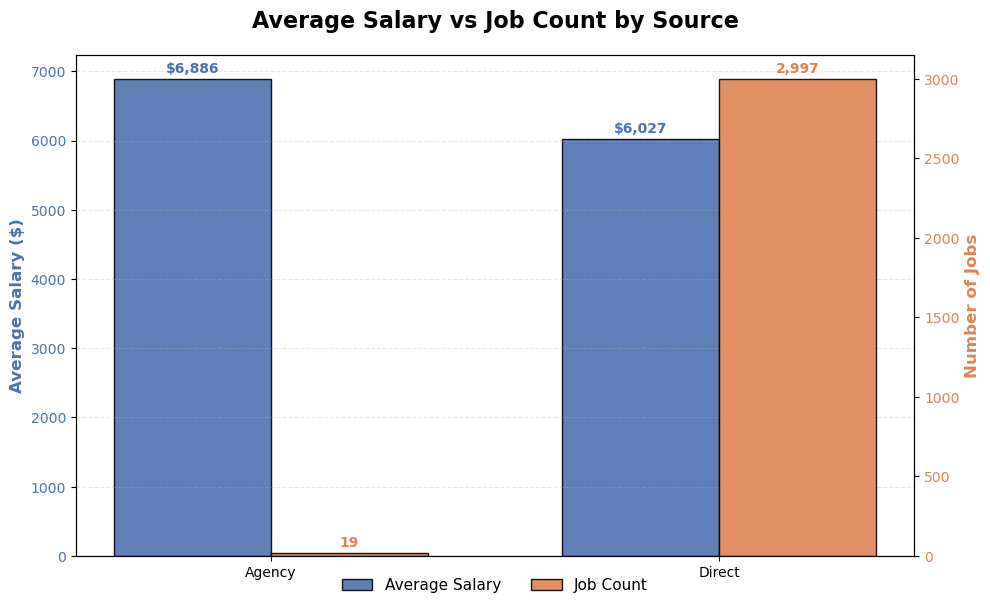

In [47]:
x = np.arange(len(combined_compare['Source']))
width = 0.35

# --- Colors ---
salary_color = '#4C72B0'   # blue
count_color = '#DD8452'    # orange

fig, ax1 = plt.subplots(figsize=(10, 6))

# LEFT AXIS → Salary
bars1 = ax1.bar(
    x - width/2,
    combined_compare['average_salary'],
    width,
    color=salary_color,
    edgecolor='black',
    alpha=0.9,
    label='Average Salary'
)

ax1.set_ylabel(
    'Average Salary ($)',
    fontsize=12,
    fontweight='bold',
    color=salary_color
)

ax1.tick_params(axis='y', labelcolor=salary_color)

# RIGHT AXIS → Job Count
ax2 = ax1.twinx()

bars2 = ax2.bar(
    x + width/2,
    combined_compare['num_jobs'],
    width,
    color=count_color,
    edgecolor='black',
    alpha=0.9,
    label='Job Count'
)

ax2.set_ylabel(
    'Number of Jobs',
    fontsize=12,
    fontweight='bold',
    color=count_color
)

ax2.tick_params(axis='y', labelcolor=count_color)

# X-axis labels
plt.xticks(
    x,
    combined_compare['Source'],
    fontsize=11,
    fontweight='bold'
)

# --- Value Labels ---
for bar in bars1:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + 50,
        f'${height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color=salary_color
    )

for bar in bars2:
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        height + 20,
        f'{height:,}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color=count_color
    )

# --- Grid ---
ax1.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

# --- Title ---
plt.title(
    'Average Salary vs Job Count by Source',
    fontsize=16,
    fontweight='bold',
    pad=20
)

# --- Legends at bottom ---
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

fig.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    frameon=False,
    fontsize=11
)

# Add extra bottom spacing
plt.tight_layout(rect=[0, 0.05, 1, 1])

plt.tight_layout()
plt.show()

## Line Trend Chart for this specific filter

In [ ]:
# Apply filters manually
trend_filtered = combined_df[filter_employtype & filter_position & filter_cat].copy()

print("Trend rows after filtering:", len(trend_filtered))

# Create pivot table
trend_pivot = (
    trend_filtered
    .pivot_table(
        index="year_month",
        columns="Source",
        values="average_salary",
        aggfunc="mean"
    )
    .reset_index()
)

# Sort by time
trend_pivot = trend_pivot.sort_values("year_month")

# Remove column index name
trend_pivot.columns.name = None

trend_pivot

Trend rows after filtering: 3016


,year_month,Agency,Direct
0,2022-10,NaN,3000.000000
1,2022-11,NaN,9000.000000
2,2022-12,NaN,4500.000000
3,2023-01,NaN,6250.000000
4,2023-02,6083.333333,4962.705882
5,2023-03,4750.000000,5440.555556
6,2023-04,NaN,6090.840000
7,2023-05,4750.000000,5890.223464
8,2023-06,NaN,6341.284689
9,2023-07,NaN,5887.364919


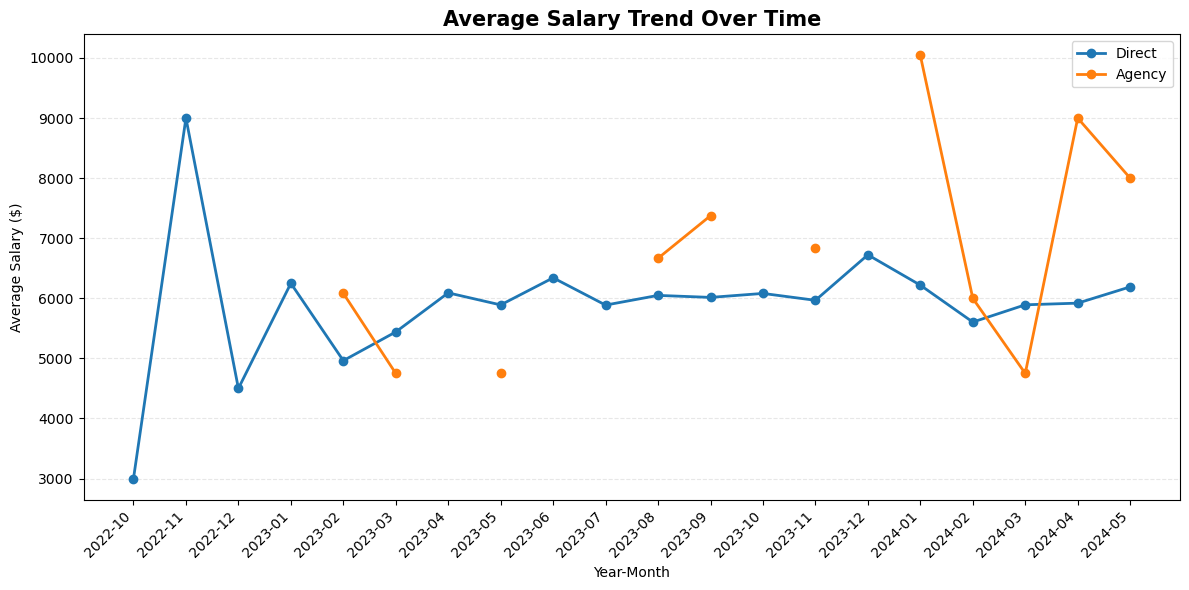

In [89]:
# Fix Period issue
plot_df["year_month"] = plot_df["year_month"].astype(str)

available_sources = [col for col in ["Direct", "Agency"] if col in plot_df.columns]

if plot_df.empty:
    print("No trend data available for the selected filters.")

elif len(available_sources) == 0:
    print("No Agency/Direct salary data available for this filter.")

else:
    plt.figure(figsize=(12, 6))

    for source in available_sources:
        plt.plot(
            plot_df["year_month"],
            plot_df[source],
            marker="o",
            linewidth=2,
            label=source
        )

    plt.title("Average Salary Trend Over Time", fontsize=15, fontweight="bold")
    plt.xlabel("Year-Month")
    plt.ylabel("Average Salary ($)")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.legend(loc="upper right")

    plt.tight_layout()
    plt.show()